# 75 - CNN Regression: recovering the generating parameters

**Section:** CNNs | **Prereqs:** `CNNs/Gaussian_Blur.ipynb` | **Next:** `CNNs/CustomLossFunctions.ipynb`

Instead of classifying the blob, predict the three numbers that *generated* it:
centre x, centre y, and width. A CNN doing **multi-output regression**.

**What changes from classification**
- Output layer has 3 units, one per target, and no activation.
- Loss is `MSELoss`; targets are floats, not class indices.
- There is no accuracy - the score is the loss, or a scatter of predicted against
  true.

**Why this is a genuinely interesting result.** The network is inverting the
generative process: given an image, recover the parameters that made it. That is
the shape of a large family of real problems - pose estimation, object
localisation, physical parameter estimation from sensor data, and the encoder half
of an autoencoder.

**Note the model must NOT be position-invariant here.** Two of the three targets
*are* position. So this model flattens its feature map rather than using global
average pooling - the exact opposite choice from the previous notebook, for the
exact opposite reason. Choosing where to be invariant is architecture design.

**The plot to trust is the last one:** predicted against true, per target. Points
on the diagonal mean the parameter was recovered. Expect the centres to be easy
and sigma to be harder, since the noise mostly obscures the blob's edges.

**Worth trying:** standardise the three targets before training. Centres run to
about +/-4 and sigma from 5 to 25, so sigma's errors dominate the MSE and the
model spends most of its capacity there.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

from torchsummary import summary

In [10]:
# 2000 blobs, each with a random centre AND a random sigma (5 to 25).
# The label is now a 3-vector [cx, cy, sigma] rather than a class index.
# (The commented-out occlusion block adds bars across the image - used in the
# autoencoder notebooks to make the task harder.)
img_size = 91
n_perClass = 2000

x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)

images = np.zeros((n_perClass , 1, img_size,img_size), dtype=float)
labels = np.zeros((n_perClass, 3))

for i in range(n_perClass):

  center = 2*np.random.randn(2)
  sigma =  np.random.rand() * 20 + 5

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma))

  noise = np.random.randn(*G.shape) / 5

  images[i,:,:,:] = G + noise
  labels[i, :] = [center[0], center[1], sigma]

  # Occulsion
  # i1 = np.random.choice(np.arange(2,28))
  # i2 = np.random.choice(np.arange(2,6))

  # if np.random.randn() > 0:
  #   images[i,:,i1:i1+i2,:] = 1
  # else:
  #   images[i,:,:,i1:i1+i2] = 1



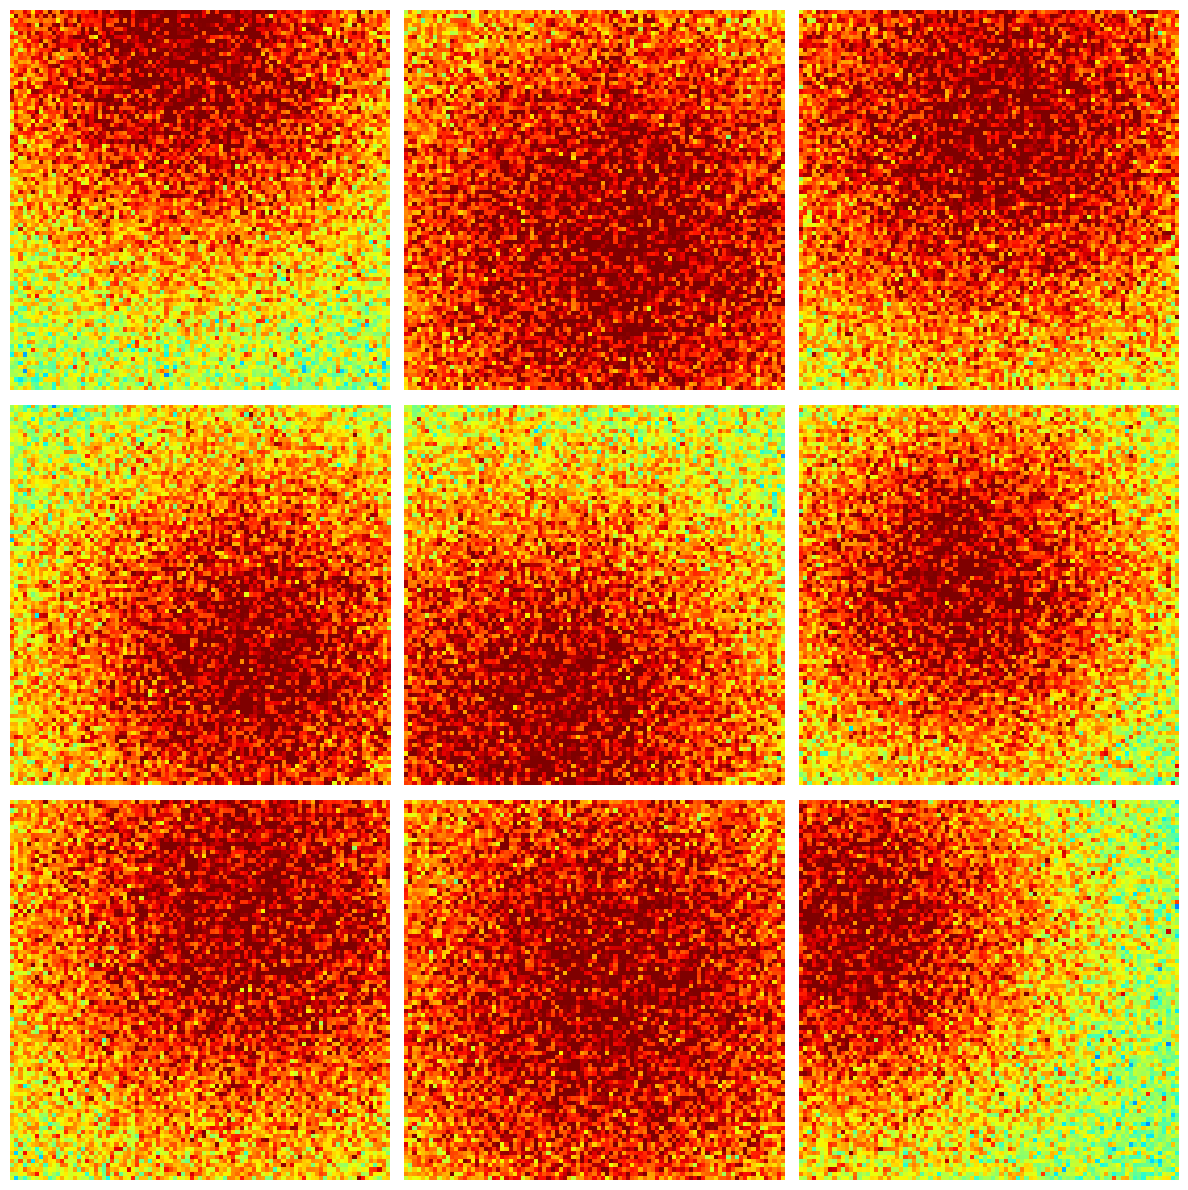

In [11]:
# Sample blobs at varying positions and widths.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Split and loaders. Labels are float32 - regression targets, not class indices.
device = ('cuda' if torch.cuda.is_available() else 'cpu')
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

train_images_tensor = torch.tensor(X_train, dtype=torch.float, device=device)
train_labels_tensor = torch.tensor(y_train, dtype=torch.float, device=device)

test_images_tensor = torch.tensor(X_test, dtype=torch.float, device=device)
test_labels_tensor = torch.tensor(y_test, dtype=torch.float, device=device)

train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)

bs = 16

train_loader = DataLoader(train_dataset, batch_size=bs, drop_last=True, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], drop_last=False, shuffle=False)

In [13]:
# Shapes: images (16,1,91,91), labels (16,3).
a,b = next(iter(train_loader))
a.shape,b.shape

(torch.Size([16, 1, 91, 91]), torch.Size([16, 3]))

## Defining the model

In [14]:
# The regression CNN. Note the deliberate design choice: nn.Flatten() and a
# Linear over the full 4*22*22 feature map, NOT global average pooling.
# Averaging over position would destroy exactly the information two of the three
# targets encode. Compare with Gaussian_Blur.ipynb, where averaging over position
# was the right call - the architecture follows from what must be preserved.
# The final Linear(50,3) has no activation: regression targets are unbounded.
from torch.nn.modules.linear import Linear
class Parameter_Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
        nn.Conv2d(1,8,kernel_size=3,padding=1,stride=1), # Output_size = [8,91,91]
        nn.ReLU(),
        nn.AvgPool2d(2,2), # Output = [8,45,45]

        nn.Conv2d(8,4,kernel_size=3, padding=1, stride=1), # Output = [4,45,45]
        nn.ReLU(),
        nn.AvgPool2d(2,2), #[4,22,22]

        nn.Flatten(),
        nn.Linear(4*22*22, 50),
        nn.ReLU(),
        nn.Linear(50,3)
    )


  def forward(self,x):
    return self.layers(x)

In [15]:
test_model = Parameter_Model()
test_model.to(device)

Parameter_Model(
  (layers): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1936, out_features=50, bias=True)
    (8): ReLU()
    (9): Linear(in_features=50, out_features=3, bias=True)
  )
)

In [16]:
# torchsummary - the flatten into Linear(1936,50) is where the parameters are.
summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 91, 91]              80
              ReLU-2            [-1, 8, 91, 91]               0
         AvgPool2d-3            [-1, 8, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             292
              ReLU-5            [-1, 4, 45, 45]               0
         AvgPool2d-6            [-1, 4, 22, 22]               0
           Flatten-7                 [-1, 1936]               0
            Linear-8                   [-1, 50]          96,850
              ReLU-9                   [-1, 50]               0
           Linear-10                    [-1, 3]             153
Total params: 97,375
Trainable params: 97,375
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.29
Params size (MB): 0.37
Estimated Tot

In [26]:
# MSELoss over all three outputs at once. Note the three targets have different
# scales (centres ~ +/-4, sigma 5-25), so sigma's errors dominate the loss.
# Standardising each target would weight them equally - worth trying.
def train_model():

  model = Parameter_Model().to(device)

  lr = 1e-3
  epochs = 10

  lossFunc = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []
  val_loss = []

  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat, y.float())
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    losses.append(np.mean(batch_loss))

    # Now Validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      val_loss.append(lossFunc(model(X),Y).item())

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]:.2f} | Val Loss : {val_loss[epoch]:.2f}')

  return losses,val_loss, model

In [27]:
losses,val_loss, model = train_model()

Epoch : 0 | loss : 23.54 | Val Loss : 7.27
Epoch : 9 | loss : 0.46 | Val Loss : 0.43


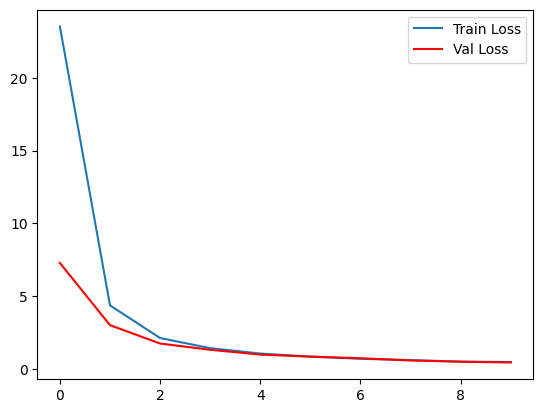

In [28]:
# Train and validation loss. No accuracy exists for regression; the loss and
# the scatter plot below are the evaluation.
plt.plot(losses, label = "Train Loss")
plt.plot(val_loss, 'r-', label="Val Loss")
plt.legend();

## Exploring the test dataset

In [51]:
# Predictions on the whole test set.
subset = test_images_tensor
subset_labels = test_labels_tensor

ouput = model(subset)

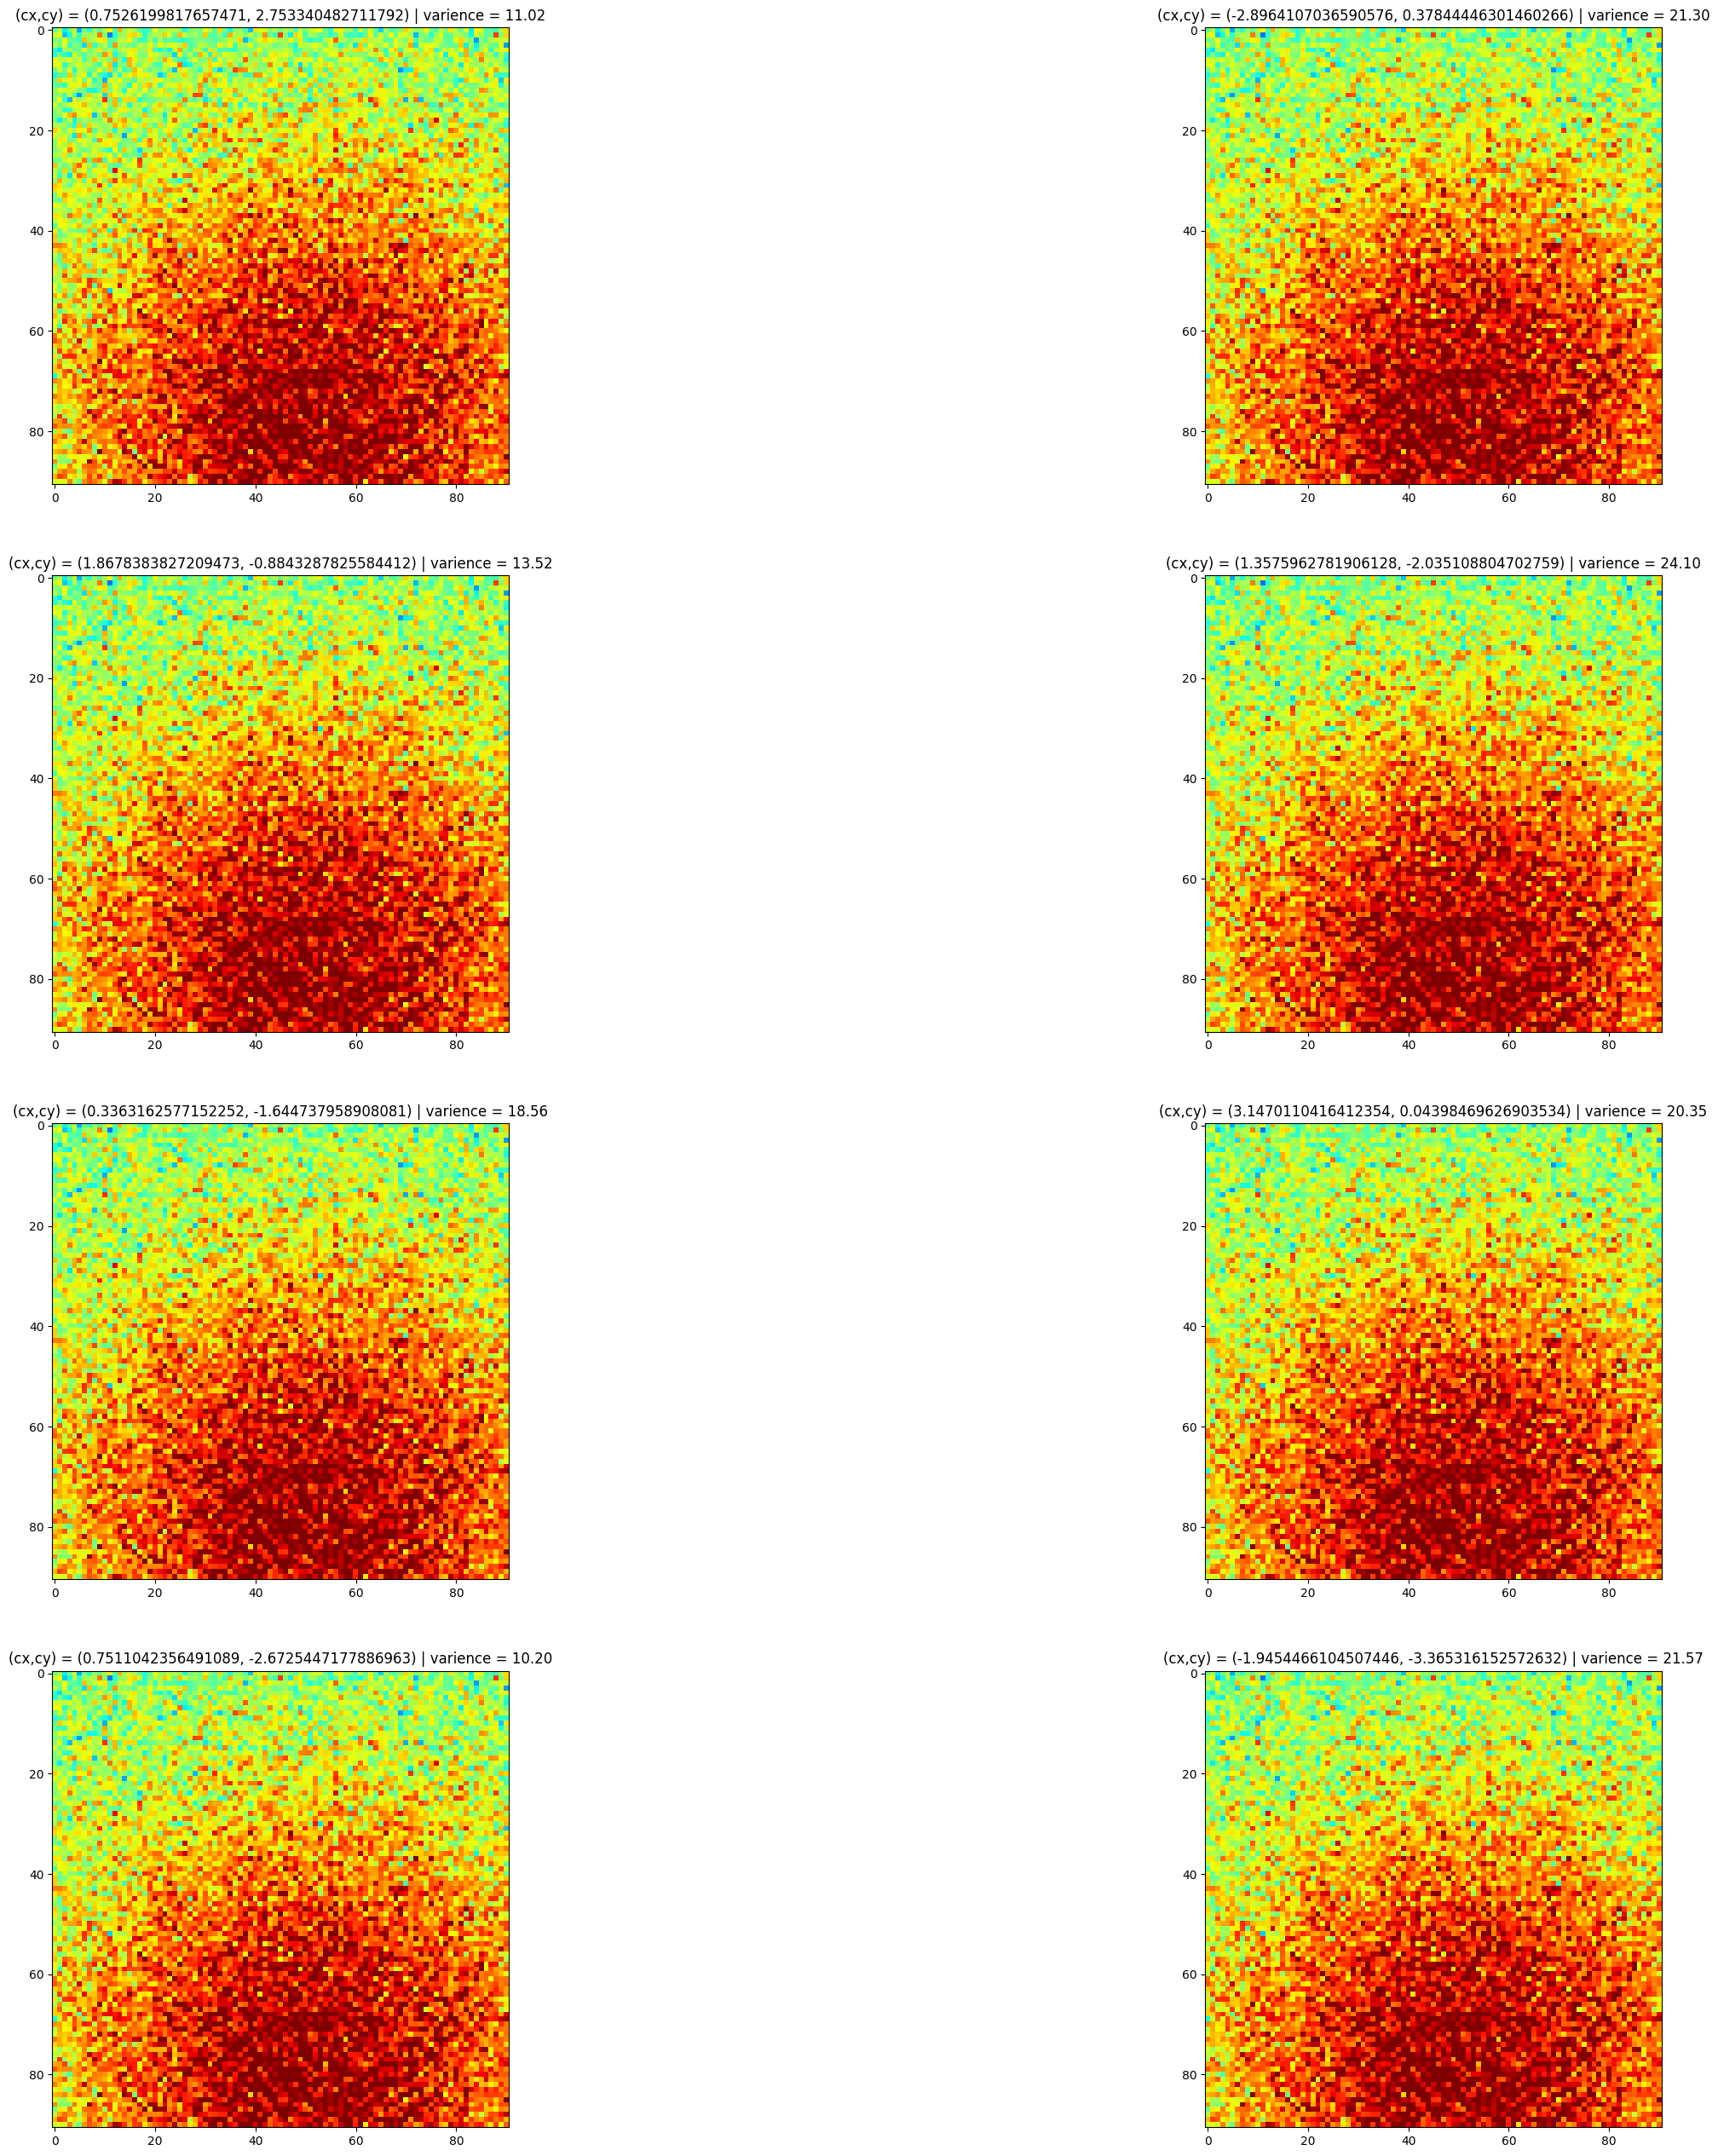

In [52]:
# Eight test images with their PREDICTED parameters in the titles.
# Each panel shows its own image, so the titles can be checked against the blob
# actually drawn.
fig, ax = plt.subplots(4,2, figsize=(32,32))
ax = ax.flatten()
for i in range(8):
  ax[i].imshow(subset[i].squeeze().cpu().numpy(), vmin=-1, vmax=1, cmap = 'jet')
  ax[i].set_title(f'(cx,cy) = {ouput[i,0].item(), ouput[i,1].item()} | varience = {ouput[i,2]:.2f}')

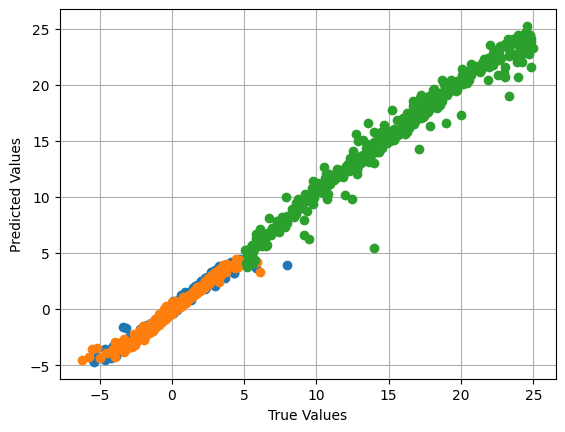

In [55]:
# The evaluation plot: predicted vs true for each of the three parameters.
# Points on the diagonal are correct. Expect the two centres to line up well and
# sigma to be noisier - the noise added to the image most obscures the blob's
# edges, which is what determines its width.
for i in range(3):
  plt.plot(subset_labels[:,i].cpu().numpy(), ouput[:,i].detach().cpu().numpy(), 'o')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.grid();

# Conclusion and Future Reference

In this notebook, we successfully:
1. **Generated Synthetic Data**: Created a dataset of 2,000 images containing Gaussian blobs with random centers and variances, including additive noise.
2. **Built a CNN for Regression**: Implemented a PyTorch model (`Parameter_Model`) designed to output 3 continuous values corresponding to the center coordinates ($c_x, c_y$) and the $\sigma$ (variance).
3. **Training & Validation**: The model was trained using Mean Squared Error (MSE) loss. We observed a significant drop in loss, indicating the model learned to localize and size the Gaussian blobs effectively.
4. **Evaluation**: Visual inspection of test samples and the 'True vs. Predicted' plot shows strong alignment, suggesting the model generalizes well to unseen synthetic data.

**Future Improvements:**
- **Occlusions**: Re-enable the occlusion logic in the data generation step to test model robustness.
- **Architecture**: Experiment with deeper architectures or different pooling layers (e.g., MaxPool) to see effects on precision.
- **Real Data**: Adapt the pipeline for real-world astronomical or medical imaging where blob detection is required.